In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
# '-' 깨짐 해결 모듈
import matplotlib as mpl
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split


plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["font.size"] = 12
plt.rcParams["figure.figsize"] = (8,4)
print(plt.rcParams["font.family"])

# 마이너스 깨짐 해결
mpl.rcParams["axes.unicode_minus"] = False

['NanumGothic']


In [2]:
from energy_consumption.paths import DATA_DIR, MODEL_DIR

In [3]:
df = pd.read_csv(DATA_DIR / "ev_energy_consumption.csv")

In [4]:
df.head()

,speed_kmh,payload_kg,ambient_temp_C,hvac_power_kw,road_grade_pct,battery_temp_C,driving_style_index,tire_pressure_bar,trip_distance_km,energy_consumption_kwhper100km
0,61.2,360.1,-9.8,3.43,-4.65,24.0,0.687,2.38,35.7,25.357
1,124.6,343.6,-10.0,2.34,-4.90,17.8,0.413,2.79,9.1,25.554
2,100.5,47.9,13.6,0.28,-2.08,18.8,0.280,2.58,68.8,18.004
3,85.9,461.3,-8.5,4.59,5.39,20.4,0.616,2.68,165.7,34.539
4,37.2,284.2,38.7,4.90,6.76,21.1,0.740,2.35,8.0,26.883


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 10 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   speed_kmh                       8000 non-null   float64
 1   payload_kg                      8000 non-null   float64
 2   ambient_temp_C                  8000 non-null   float64
 3   hvac_power_kw                   8000 non-null   float64
 4   road_grade_pct                  8000 non-null   float64
 5   battery_temp_C                  8000 non-null   float64
 6   driving_style_index             8000 non-null   float64
 7   tire_pressure_bar               8000 non-null   float64
 8   trip_distance_km                8000 non-null   float64
 9   energy_consumption_kwhper100km  8000 non-null   float64
dtypes: float64(10)
memory usage: 625.1 KB


In [6]:
df.describe()

,speed_kmh,payload_kg,ambient_temp_C,hvac_power_kw,road_grade_pct,battery_temp_C,driving_style_index,tire_pressure_bar,trip_distance_km,energy_consumption_kwhper100km
count,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,74.427013,248.822563,15.587013,2.477026,1.464087,29.970725,0.499641,2.401016,102.692337,24.137613
std,31.789245,144.327869,14.396150,1.435208,3.744704,8.717058,0.286885,0.230790,55.844911,3.738082
min,20.000000,0.000000,-10.000000,0.000000,-5.000000,15.000000,0.000000,2.000000,5.100000,11.620000
25%,46.775000,124.300000,3.475000,1.230000,-1.790000,22.300000,0.254000,2.200000,54.300000,21.514000
50%,74.200000,246.850000,15.800000,2.480000,1.500000,29.900000,0.502000,2.400000,103.250000,24.092500
75%,101.800000,376.125000,27.900000,3.700000,4.670000,37.700000,0.745000,2.600000,151.700000,26.753000
max,130.000000,500.000000,40.000000,5.000000,8.000000,45.000000,1.000000,2.800000,200.000000,35.000000


In [7]:
# 결측치 없다
df.isna().sum()

speed_kmh                         0
payload_kg                        0
ambient_temp_C                    0
hvac_power_kw                     0
road_grade_pct                    0
battery_temp_C                    0
driving_style_index               0
tire_pressure_bar                 0
trip_distance_km                  0
energy_consumption_kwhper100km    0
dtype: int64

In [8]:
# 중복 데이터도 없다
df.duplicated().sum()

np.int64(0)

In [9]:
# 독립변수 종속변수 분리
X = df.drop(columns=['energy_consumption_kwhper100km'])
y = df['energy_consumption_kwhper100km']

In [10]:
X.head()

,speed_kmh,payload_kg,ambient_temp_C,hvac_power_kw,road_grade_pct,battery_temp_C,driving_style_index,tire_pressure_bar,trip_distance_km
0,61.2,360.1,-9.8,3.43,-4.65,24.0,0.687,2.38,35.7
1,124.6,343.6,-10.0,2.34,-4.90,17.8,0.413,2.79,9.1
2,100.5,47.9,13.6,0.28,-2.08,18.8,0.280,2.58,68.8
3,85.9,461.3,-8.5,4.59,5.39,20.4,0.616,2.68,165.7
4,37.2,284.2,38.7,4.90,6.76,21.1,0.740,2.35,8.0


In [11]:
y.head()

0    25.357
1    25.554
2    18.004
3    34.539
4    26.883
Name: energy_consumption_kwhper100km, dtype: float64

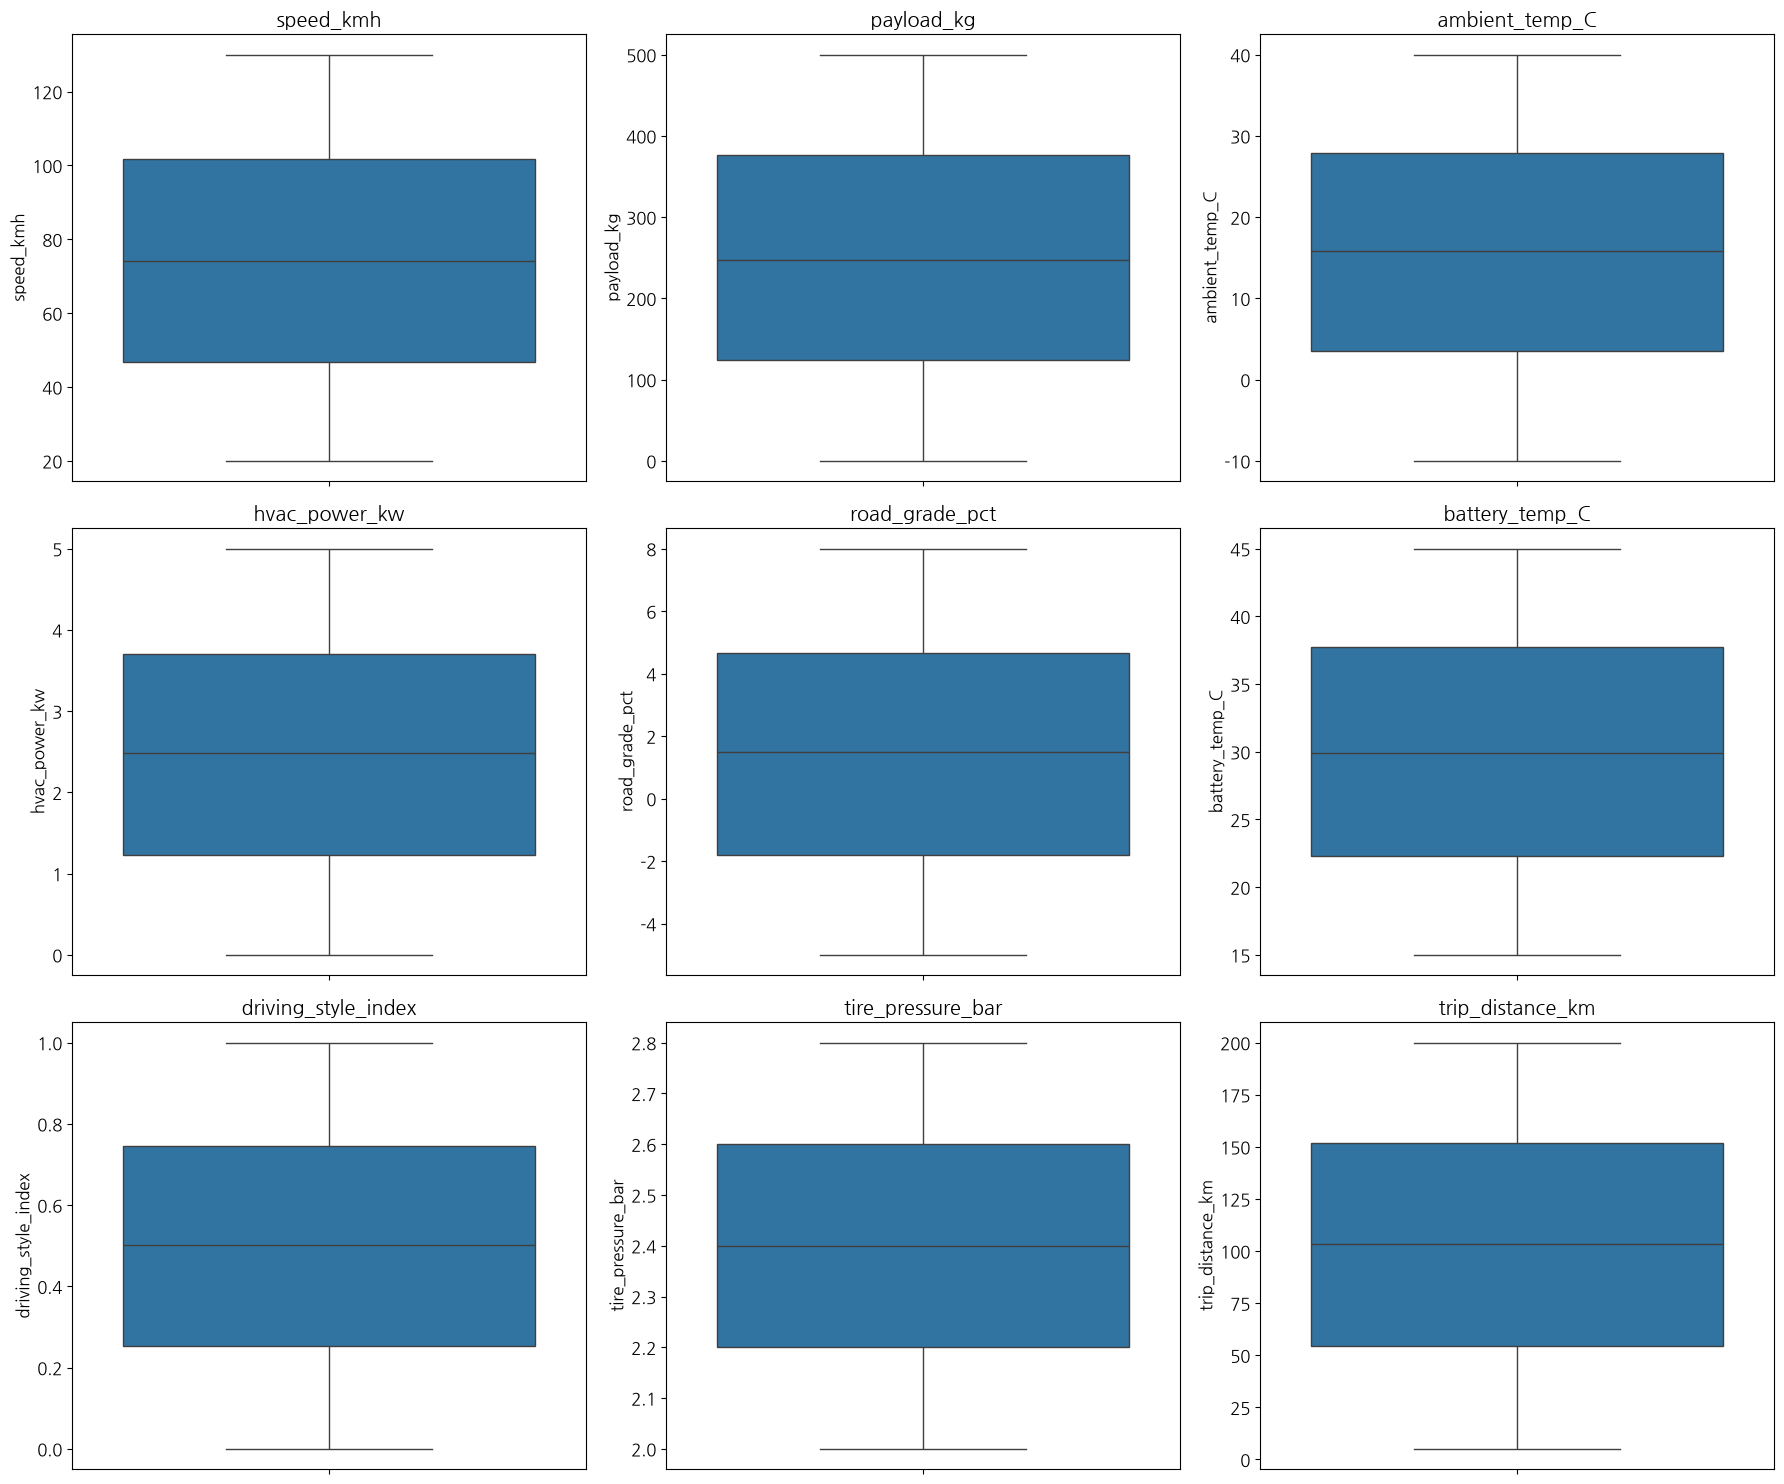

In [12]:
# 데이터 분포 확인
figure, axes = plt.subplots(3, 3, figsize=(18, 15))

axes = axes.flatten()

for i, col in enumerate(X.columns):
    sns.boxplot(data=X, y=col, ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

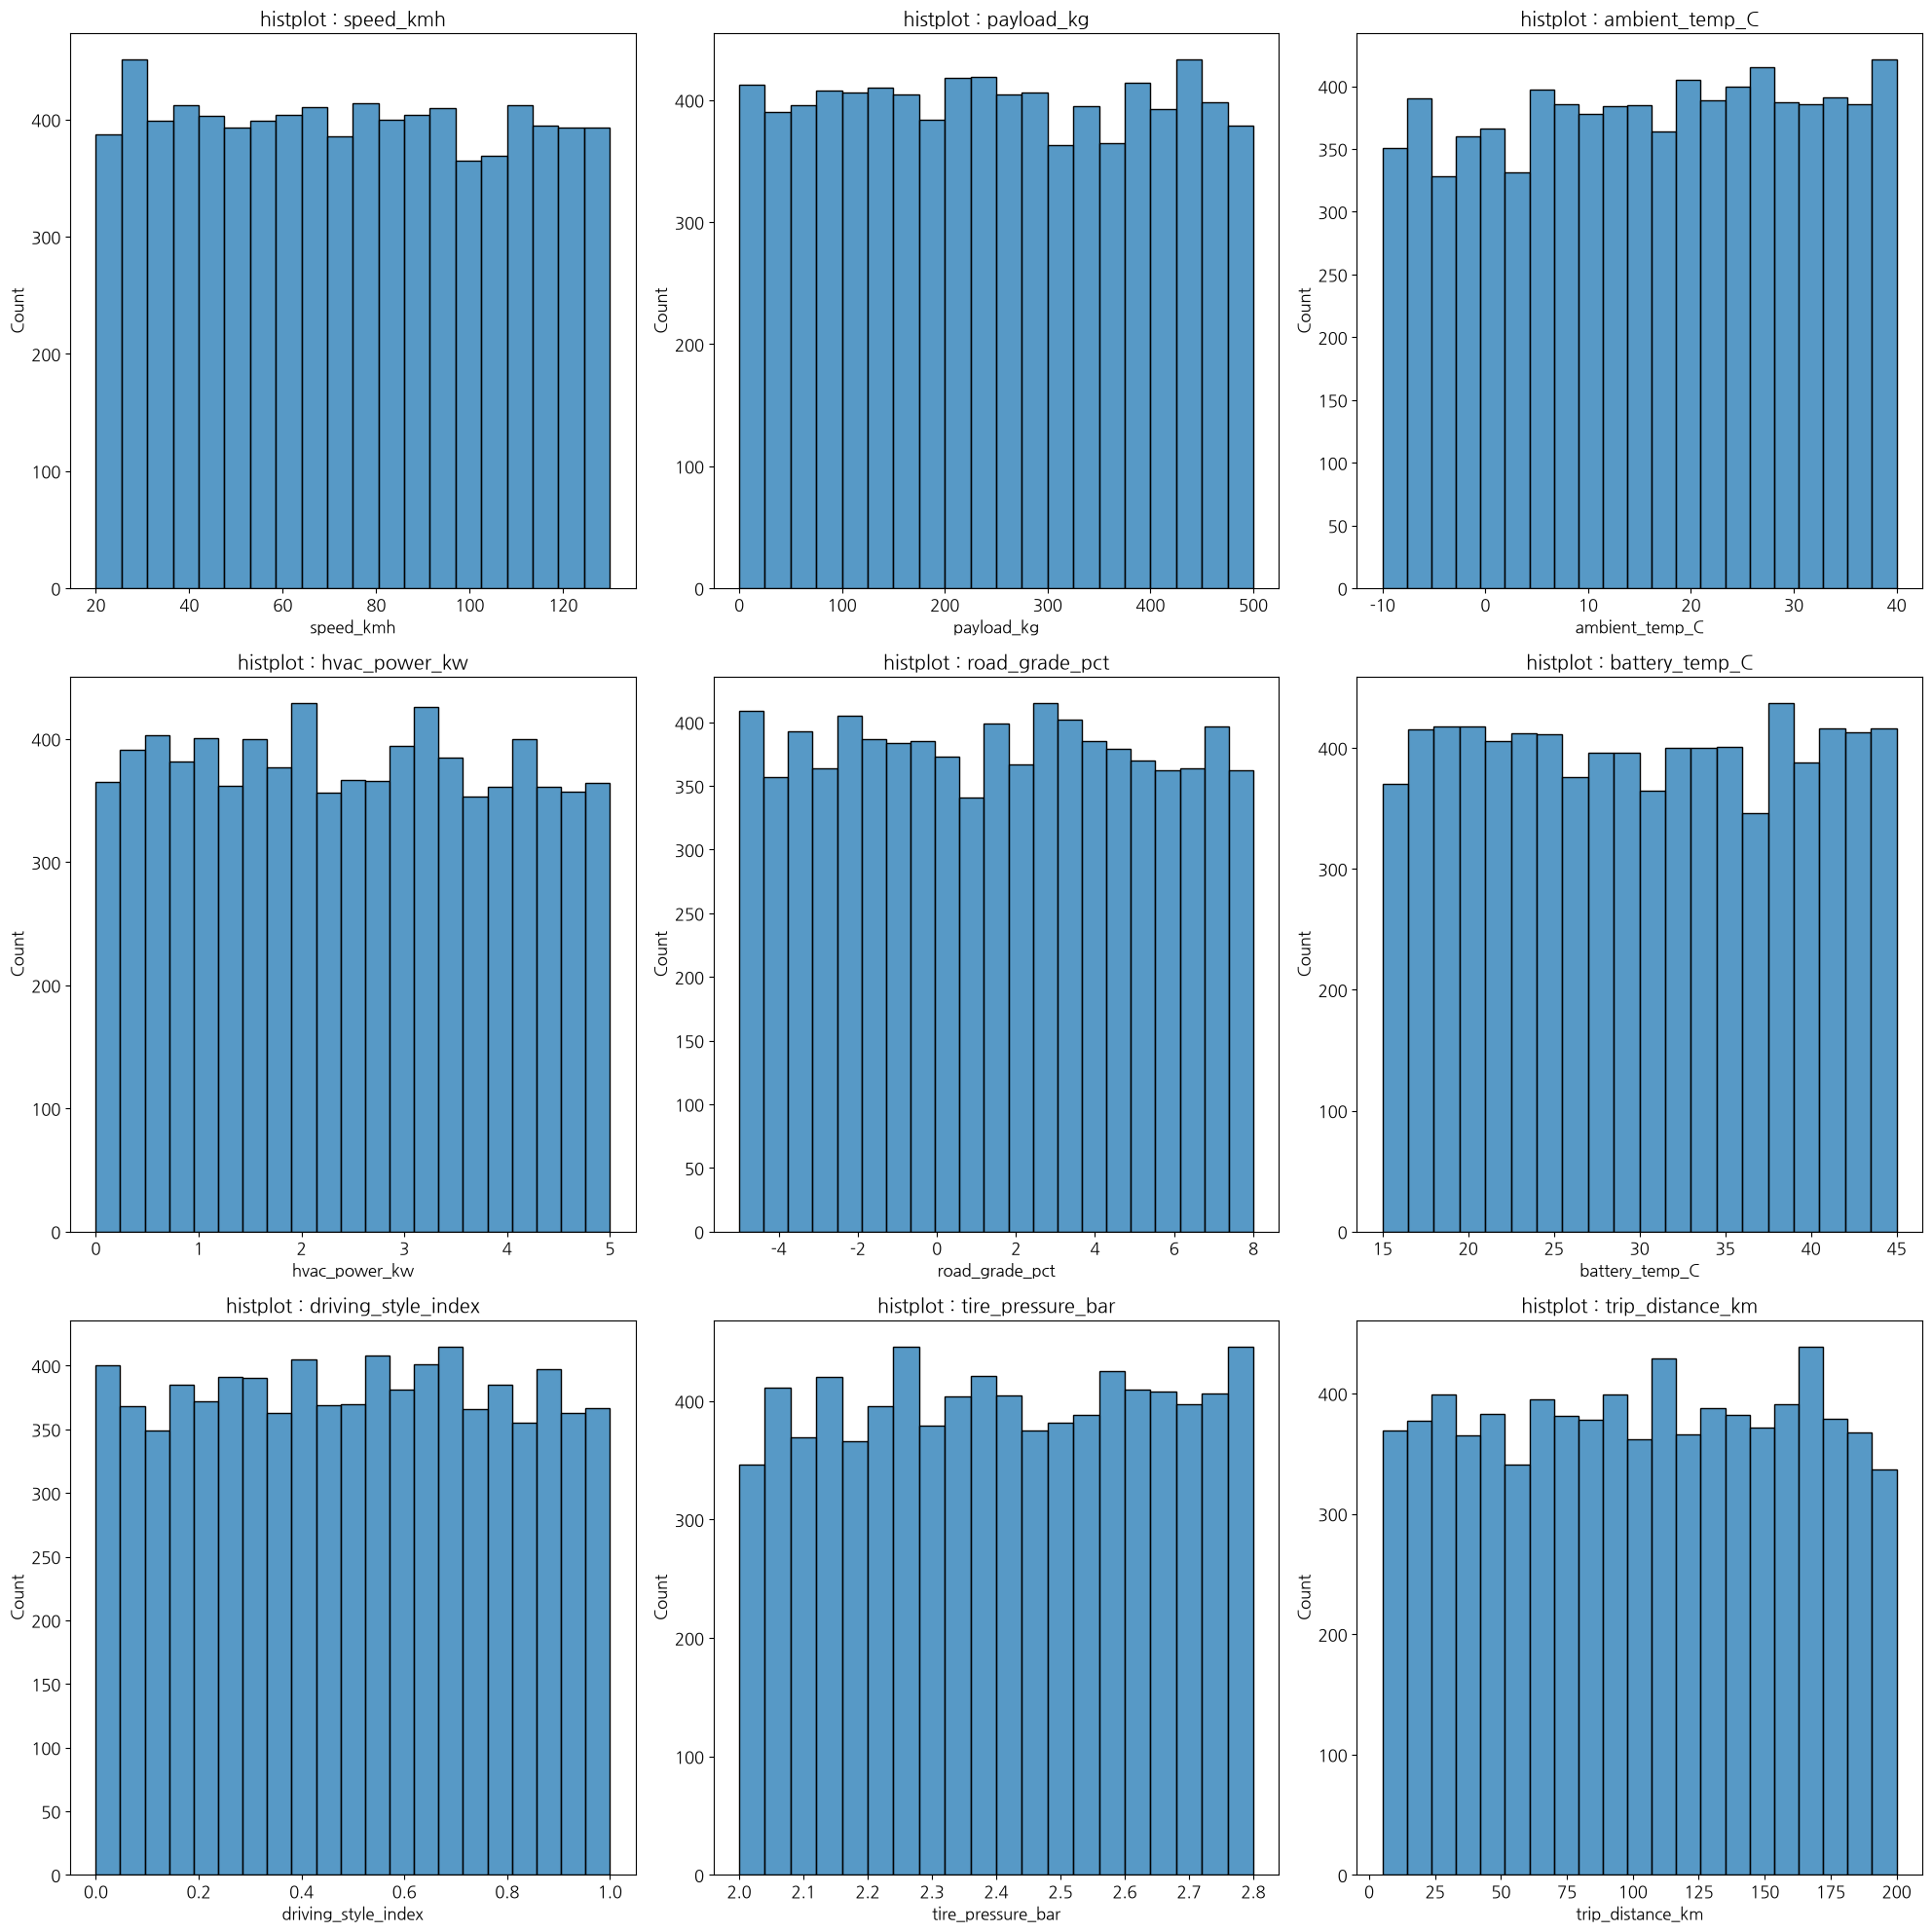

In [13]:
nrows, ncols = 3, 3
figure, axes = plt.subplots(nrows = nrows, ncols=ncols)
figure.set_size_inches(20, 20)

axes = axes.flatten()
col_names = X.columns

for i, col in enumerate(col_names):
    ax = sns.histplot(
        data = X, 
        x = col, 
        ax = axes[i]
    )
    ax.set_title("histplot : " + col)

plt.tight_layout()
plt.show()

In [14]:
# 이상치 확인
Q1 = X.quantile(0.25)
Q3 = X.quantile(0.75)

IQR = Q3 - Q1       # Q3과 Q1 사이의 거리   # 이 사이엔 중앙 데이터가 들어있다

outliers = (
    (X < (Q1 - 1.5 * IQR)) |    # 1.5는 공식으로 나온 값이 아니라 똑똑하신 분이 만든 여유값
    (X > (Q3 + 1.5 * IQR))
)

outliers.sum()

speed_kmh              0
payload_kg             0
ambient_temp_C         0
hvac_power_kw          0
road_grade_pct         0
battery_temp_C         0
driving_style_index    0
tire_pressure_bar      0
trip_distance_km       0
dtype: int64

In [15]:
# 이상치 확인
yQ1 = y.quantile(0.25)
yQ3 = y.quantile(0.75)

yIQR = yQ3 - yQ1

y_outliers = (
    (y < (yQ1 - 1.5 * yIQR)) | (y > (yQ3 + 1.5 * yIQR))
)

y_outliers.sum()

np.int64(21)

In [16]:
# 어떤 것들이 이상치인가?
y[y_outliers]

208     13.280
1106    13.065
1225    35.000
1481    11.620
2074    34.621
2860    34.912
2979    35.000
3177    35.000
3728    12.307
3768    12.192
4321    35.000
5449    12.955
5512    35.000
6295    35.000
6420    35.000
6434    35.000
6711    13.583
6867    13.548
7208    13.595
7310    35.000
7910    34.903
Name: energy_consumption_kwhper100km, dtype: float64

In [17]:
# 이상치 비율
y_outliers.mean() * 100

np.float64(0.2625)

In [18]:
# 상관계수
# 각 feature와 에너지 소비량 사이의 선형 상관관계 확인

corr_df = df.corr()

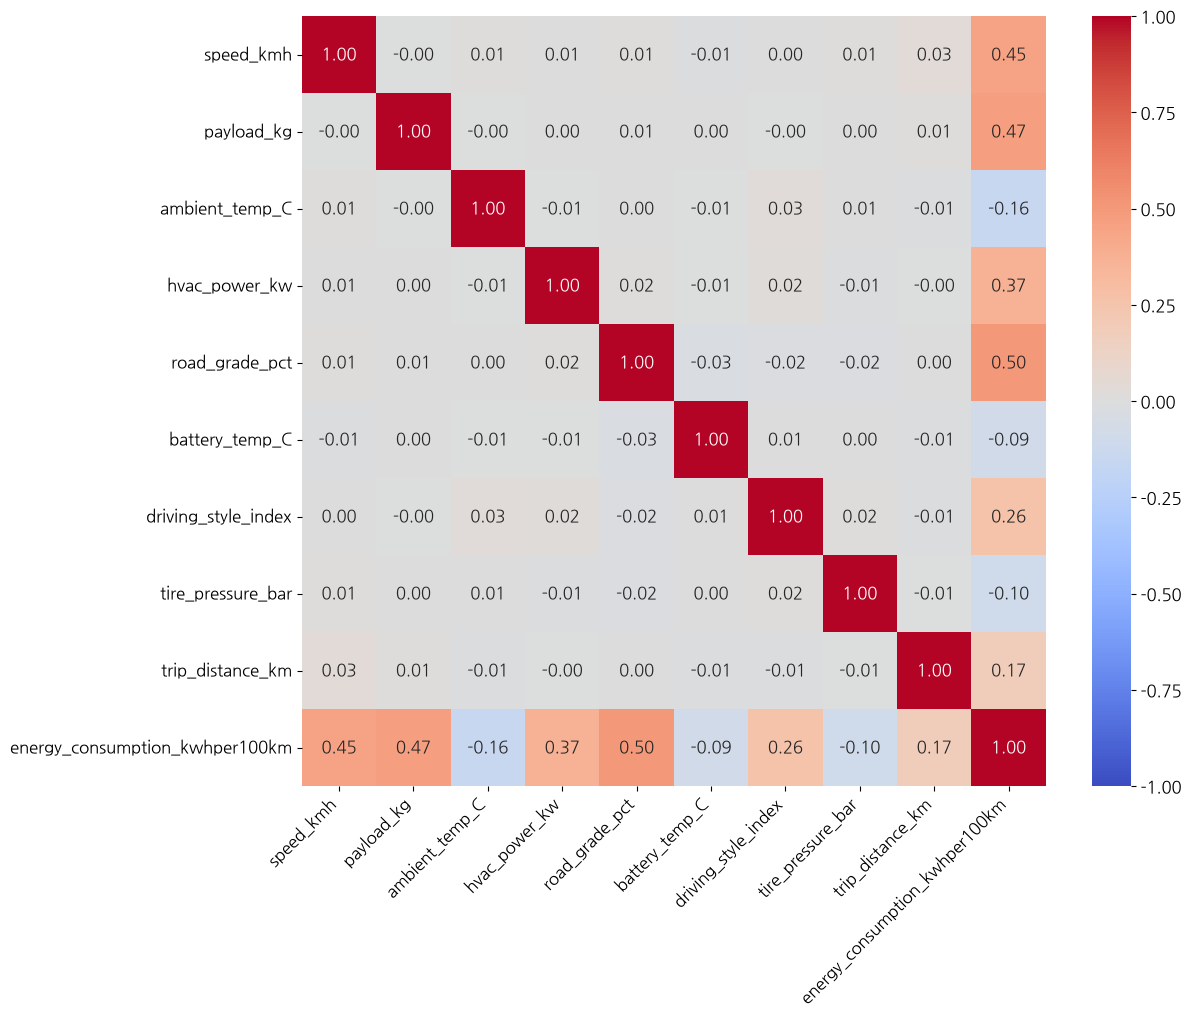

In [19]:
plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_df,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    center=0
)

plt.xticks(rotation=45, ha='right')

plt.show()

In [20]:
# 상관계수를 높은 순으로 확인해보자
target_col = 'energy_consumption_kwhper100km'   # 얘는 1이 나오니까 제외

target_corr = corr_df[target_col].drop(target_col)

target_corr = target_corr.loc[
    target_corr.abs().sort_values(ascending=False).index
]

target_corr

road_grade_pct         0.504623
payload_kg             0.468906
speed_kmh              0.448316
hvac_power_kw          0.369619
driving_style_index    0.258434
trip_distance_km       0.171982
ambient_temp_C        -0.155499
tire_pressure_bar     -0.095066
battery_temp_C        -0.086873
Name: energy_consumption_kwhper100km, dtype: float64

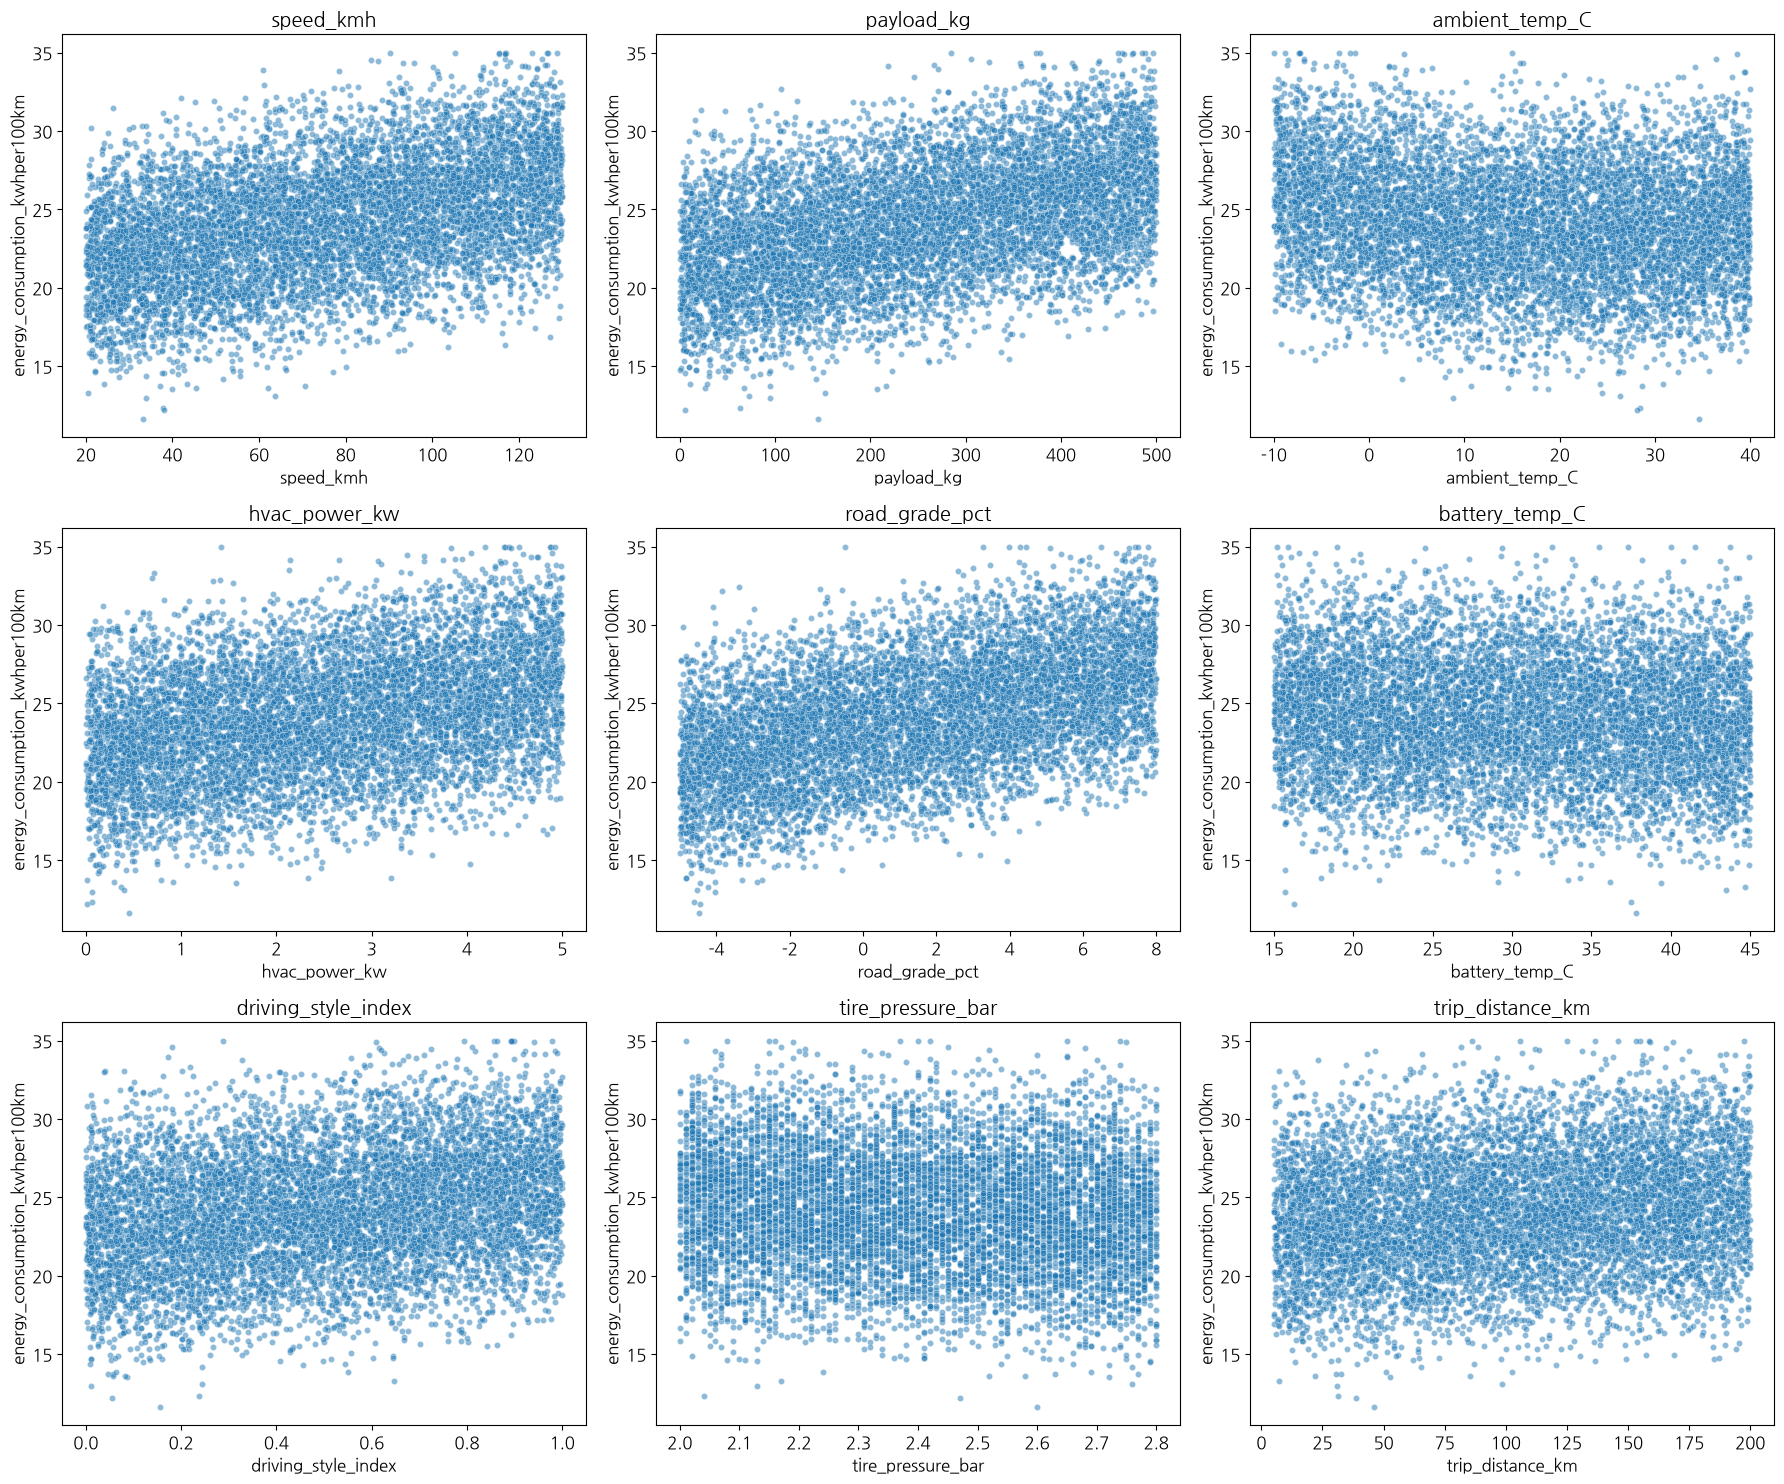

In [21]:
# 산점도
figure, axes = plt.subplots(
    nrows=3,
    ncols=3,
    figsize=(18, 15)
)

axes = axes.flatten()

for i, col in enumerate(X.columns):
    sns.scatterplot(
        data=df,
        x=col,
        y='energy_consumption_kwhper100km',
        ax=axes[i],
        alpha=0.5,
        s=20
    )

    axes[i].set_title(f'{col}')

plt.tight_layout()
plt.show()

In [22]:
# train, test 분리

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=0
)

In [23]:
# 모델 성능 비교

In [24]:
# 여러 모델, 스케일러 쓸거니까 파이프라인 활용
from sklearn.pipeline import Pipeline

In [25]:
from sklearn.model_selection import cross_validate, KFold

In [26]:
# k-fold
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=0
)

In [27]:
# 모델 성능 비교용 더미
# 내가 만든 모델이 걍 평균값 넣어서 돌리는 것보다 나은가?

from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

dummy_model = DummyRegressor(strategy='mean')

dummy_model.fit(X_train, y_train)

dummy_pred = dummy_model.predict(X_test)

dummy_mae = mean_absolute_error(y_test, dummy_pred)
dummy_rmse = mean_squared_error(y_test, dummy_pred) ** 0.5
dummy_r2 = r2_score(y_test, dummy_pred)

print('MAE:', dummy_mae)
print('RMSE:', dummy_rmse)
print('R2:', dummy_r2)

MAE: 2.9871433710937496
RMSE: 3.673850642488144
R2: -0.001501061460906783


In [28]:
dummy_pipeline = Pipeline([
    ('model', DummyRegressor(strategy='mean'))
])

dummy_cv = cross_validate(
    dummy_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=[
        'neg_mean_absolute_error',
        'neg_root_mean_squared_error',
        'r2'
    ]
)

print('CV MAE:', -dummy_cv['test_neg_mean_absolute_error'].mean())
print('CV RMSE:', -dummy_cv['test_neg_root_mean_squared_error'].mean())
print('CV R2:', dummy_cv['test_r2'].mean())

CV MAE: 3.0349176599121095
CV RMSE: 3.754193670695206
CV R2: -0.0015717372044963707


- ↑ 이거보단 잘 나와야함

In [29]:
# LinearRegression
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

linear_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

linear_cv = cross_validate(
    linear_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=[
        'neg_mean_absolute_error',
        'neg_root_mean_squared_error',
        'r2'
    ]
)

In [30]:
print('CV MAE:', -linear_cv['test_neg_mean_absolute_error'].mean())
print('CV RMSE:', -linear_cv['test_neg_root_mean_squared_error'].mean())
print('CV R2:', linear_cv['test_r2'].mean())

CV MAE: 0.8122689125522324
CV RMSE: 1.0120573572032954
CV R2: 0.9270986544594086


In [31]:
# KNN
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor

knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsRegressor())
])

# knn_pipeline.fit(X_train, y_train)

# knn_pred = knn_pipeline.predict(X_test)

# knn_mae = mean_absolute_error(y_test, knn_pred)
# knn_rmse = mean_squared_error(y_test, knn_pred) ** 0.5
# knn_r2 = r2_score(y_test, knn_pred)

In [32]:
# print('MAE:', knn_mae)
# print('RMSE:', knn_rmse)
# print('R2:', knn_r2)

In [33]:
knn_cv = cross_validate(
    knn_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=[
        'neg_mean_absolute_error',
        'neg_root_mean_squared_error',
        'r2'
    ]
)

In [34]:
print('CV MAE:', -knn_cv['test_neg_mean_absolute_error'].mean())
print('CV RMSE:', -knn_cv['test_neg_root_mean_squared_error'].mean())
print('CV R2:', knn_cv['test_r2'].mean())

CV MAE: 1.0770231875000003
CV RMSE: 1.351492697628528
CV R2: 0.8700076305980705


In [35]:
# 랜덤포레스트
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline([
    ('model', RandomForestRegressor(
        random_state=0
    ))
])

rf_cv = cross_validate(
    rf_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=[
        'neg_mean_absolute_error',
        'neg_root_mean_squared_error',
        'r2'
    ]
)

In [36]:
print('CV MAE:', -rf_cv['test_neg_mean_absolute_error'].mean())
print('CV RMSE:', -rf_cv['test_neg_root_mean_squared_error'].mean())
print('CV R2:', rf_cv['test_r2'].mean())

CV MAE: 0.9893240796875002
CV RMSE: 1.2330999720931515
CV R2: 0.891784230393719


In [37]:
# xgboost

from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor

xgb_pipeline = Pipeline([
    ('model', XGBRegressor(
        random_state=0
    ))
])

xgb_cv = cross_validate(
    xgb_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=[
        'neg_mean_absolute_error',
        'neg_root_mean_squared_error',
        'r2'
    ]
)

In [38]:
print('CV MAE:', -xgb_cv['test_neg_mean_absolute_error'].mean())
print('CV RMSE:', -xgb_cv['test_neg_root_mean_squared_error'].mean())
print('CV R2:', xgb_cv['test_r2'].mean())

CV MAE: 0.8912741210484505
CV RMSE: 1.1092293385781737
CV R2: 0.9123626397162832


In [39]:
# 시각화는 보기 쉽게 하는 것이 정수다

def get_cv_result(name, cv_result):
    return {
        'model': name,
        'MAE': -cv_result['test_neg_mean_absolute_error'].mean(),
        'RMSE': -cv_result['test_neg_root_mean_squared_error'].mean(),
        'R2': cv_result['test_r2'].mean()
    }

In [40]:
results = [
    get_cv_result('Dummy', dummy_cv),
    get_cv_result('LinearRegression', linear_cv),
    get_cv_result('KNN', knn_cv),
    get_cv_result('Random Forest', rf_cv),
    get_cv_result('xgboost', xgb_cv)
]

result_df = pd.DataFrame(results)
# result_df.loc[len(result_df)] = {
#     'model': 'dummy',
#     'MAE': dummy_mae,
#     'RMSE': dummy_rmse,
#     'R2': dummy_r2
# }

result_df

,model,MAE,RMSE,R2
0,Dummy,3.034918,3.754194,-0.001572
1,LinearRegression,0.812269,1.012057,0.927099
2,KNN,1.077023,1.351493,0.870008
3,Random Forest,0.989324,1.233100,0.891784
4,xgboost,0.891274,1.109229,0.912363


In [41]:
# 이제 튜닝하자     # 소비량 예측에서 오차를 가장 큰 패널티 -> RMSE 기준
from sklearn.model_selection import GridSearchCV

In [42]:
# KNN 파라미터
knn_param_grid = {
    'model__n_neighbors': [3, 5, 7, 9, 11, 15, 21],
    'model__weights': ['uniform', 'distance'],
    'model__p': [1, 2]
}

knn_grid = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=knn_param_grid,
    scoring='neg_root_mean_squared_error',
    cv=cv,
    n_jobs=-1
)

In [43]:
knn_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...Regressor())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__n_neighbors': [3, 5, ...], 'model__p': [1, 2], 'model__weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for c

In [44]:
print('Best Parameters:')
print(knn_grid.best_params_)

print('Best CV RMSE:')
print(-knn_grid.best_score_)

Best Parameters:
{'model__n_neighbors': 11, 'model__p': 2, 'model__weights': 'distance'}
Best CV RMSE:
1.2726990980972839


In [45]:
# xgboost 파라미터
xgb_param_grid = {
    'model__n_estimators': [200, 300, 500],
    'model__learning_rate': [0.03, 0.05, 0.1],
    'model__max_depth': [3, 4, 5],
    'model__subsample': [0.8, 1.0],
    'model__colsample_bytree': [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=xgb_param_grid,
    scoring='neg_root_mean_squared_error',
    cv=cv,
    n_jobs=-1
)

In [46]:
xgb_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__colsample_bytree': [0.8, 1.0], 'model__learning_rate': [0.03, 0.05, ...], 'model__max_depth': [3, 4, ...], 'model__n_estimators': [200, 300, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity 

In [47]:
print('Best Parameters:')
print(xgb_grid.best_params_)

print('Best CV RMSE:')
print(-xgb_grid.best_score_)

Best Parameters:
{'model__colsample_bytree': 0.8, 'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 500, 'model__subsample': 0.8}
Best CV RMSE:
0.8872731055833889


In [48]:
# random forest 파라미터
rf_param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2]
}

rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    scoring='neg_root_mean_squared_error',
    cv=cv,
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...om_state=0))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [None, 10, ...], 'model__min_samples_leaf': [1, 2], 'model__min_samples_split': [2, 5], 'model__n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-vali

In [49]:
print('Best Parameters:')
print(rf_grid.best_params_)

print('Best CV RMSE:')
print(-rf_grid.best_score_)

Best Parameters:
{'model__max_depth': 20, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 300}
Best CV RMSE:
1.2221250126729655


In [50]:
# 결과 비교
results = {
    'Model': [
        'Linear Regression',
        'KNN',
        'KNN Tuned',
        'Random Forest',
        'Random Forest Tuned',
        'XGBoost',
        'XGBoost Tuned'
    ],
    'RMSE': [
        result_df.loc[result_df['model'] == 'LinearRegression', 'RMSE'].iloc[0],
        result_df.loc[result_df['model'] == 'KNN', 'RMSE'].iloc[0],
        -knn_grid.best_score_,
        result_df.loc[result_df['model'] == 'Random Forest', 'RMSE'].iloc[0],
        -rf_grid.best_score_,
        result_df.loc[result_df['model'] == 'xgboost', 'RMSE'].iloc[0],
        -xgb_grid.best_score_
    ]
}

In [67]:
df_rmse_results = pd.DataFrame(results)

df_rmse_results

,Model,RMSE
0,Linear Regression,1.012057
1,KNN,1.351493
2,KNN Tuned,1.272699
3,Random Forest,1.233100
4,Random Forest Tuned,1.222125
5,XGBoost,1.109229
6,XGBoost Tuned,0.887273


In [52]:
# 튜닝한 xgboost 모델이 제일 RMSE가 낮다
# train 성능과 비교

train_pred = xgb_grid.best_estimator_.predict(X_train)

train_rmse = mean_squared_error(
    y_train,
    train_pred
) ** 0.5

print('Train RMSE:', train_rmse)
print('CV RMSE:', -xgb_grid.best_score_)

Train RMSE: 0.725987475672402
CV RMSE: 0.8872731055833889


In [53]:
# Train RMSE와 CV RMSE 차이가 거의 안 남 -> 별 문제 없으니 베스트 모델로 선정
best_model = xgb_grid.best_estimator_

In [54]:
final_pred = best_model.predict(X_test)

In [55]:
# 정리 및 최종 평가
final_mae = mean_absolute_error(
    y_test,
    final_pred
)

final_rmse = mean_squared_error(
    y_test,
    final_pred
) ** 0.5

final_r2 = r2_score(
    y_test,
    final_pred
)

print('Final MAE:', final_mae)
print('Final RMSE:', final_rmse)
print('Final R2:', final_r2)

Final MAE: 0.659964651503563
Final RMSE: 0.8335883388829255
Final R2: 0.9484401455946203


In [56]:
# 모델을 내보내자
from joblib import dump, load

In [57]:
# 컬럼 순서가 바뀌면 문제가 될 수 있다
feature_columns = X.columns.tolist()

model_data = {
    'model': best_model,
    'feature_columns': X.columns.tolist(),
    'target_column': 'energy_consumption_kwhper100km',
    'best_params': xgb_grid.best_params_,
    'metrics': {
        'MAE': final_mae,
        'RMSE': final_rmse,
        'R2': final_r2
    }
}

In [58]:
dump(model_data,  MODEL_DIR / "energy_consumption_best_model.joblib")

['/home/aiuser/energy_consumption/model/energy_consumption_best_model.joblib']

In [61]:
# 잘 저장되고 로드 되는지 확인
loaded_model = load(MODEL_DIR / "energy_consumption_best_model.joblib")['model']

In [62]:
loaded_pred = loaded_model.predict(X_test)

In [63]:
# 동일하다
loaded_r2 = r2_score(
    y_test,
    loaded_pred
)

loaded_r2

0.9484401455946203

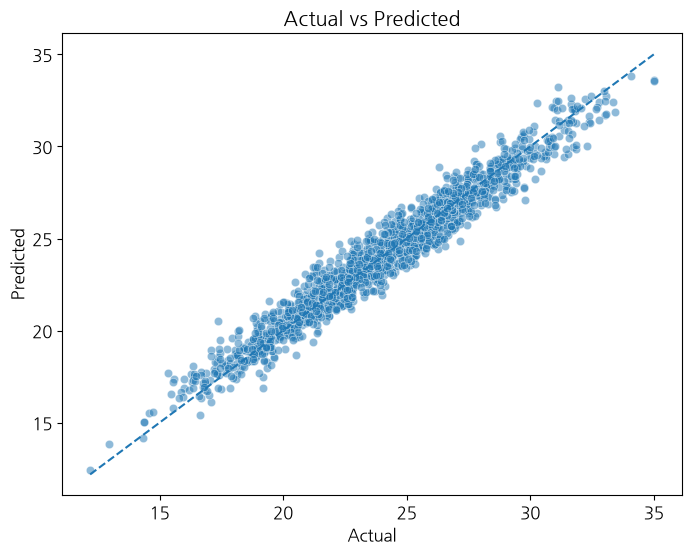

In [64]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=y_test,
    y=final_pred,
    alpha=0.5
)

min_value = min(y_test.min(), final_pred.min())
max_value = max(y_test.max(), final_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle='--'
)

plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted')

plt.show()

In [65]:
xgb_model = best_model.named_steps['model']

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
})

importance_df = importance_df.sort_values(
    'Importance',
    ascending=False
)

importance_df

,Feature,Importance
4,road_grade_pct,0.252125
1,payload_kg,0.215704
0,speed_kmh,0.185590
3,hvac_power_kw,0.141770
6,driving_style_index,0.084400
2,ambient_temp_C,0.055855
8,trip_distance_km,0.037347
7,tire_pressure_bar,0.016192
5,battery_temp_C,0.011016


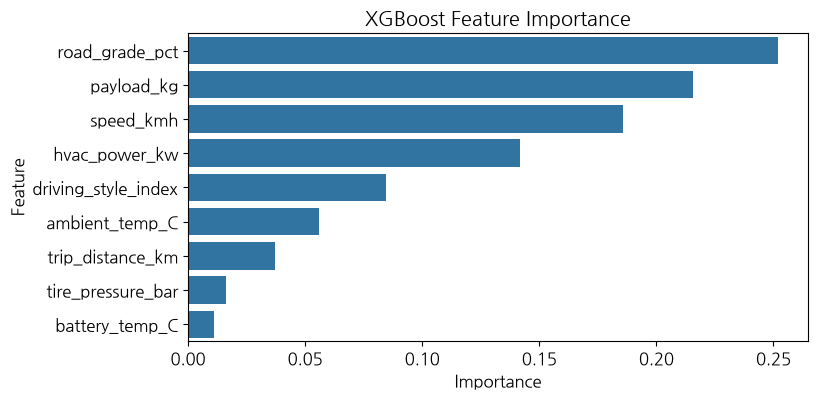

In [66]:
sns.barplot(
    data=importance_df,
    x='Importance',
    y='Feature'
)

plt.title('XGBoost Feature Importance')
plt.show()